# Best-start vs mean policy analysis

This notebook compares two hierarchical aggregation strategies:
1. `random` uses subset mean, all other policies use subset best start.
2. `random` uses subset mean, all other policies also use subset mean.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys


REPO_ROOT = Path('/data/ddmg/mvseg-ordering')
for extra_path in [REPO_ROOT, REPO_ROOT / 'UniverSeg', REPO_ROOT / 'MultiverSeg']:
    if str(extra_path) not in sys.path:
        sys.path.append(str(extra_path))

from experiments.analysis.hierarchical_ci import hierarchical_bootstrap_dataset_stat
from experiments.analysis.planb_utils import load_planb_summaries


In [2]:
# Config

PROCEDURE = 'random_v_MSE_v2'
ABLATION = 'pretrained_baseline5p_mse_embedding_context_mean'
DATASET = 'BTCV'  # Set to None for all datasets.
METRIC = 'iterations_used'  # e.g. iterations_used, initial_dice, final_dice, score
BASELINE_POLICY = 'random'

N_BOOT = 500
SEED = 0

SAVE_OUTPUTS = False

In [3]:
planb_rows = load_planb_summaries(
    repo_root=REPO_ROOT,
    procedure=PROCEDURE,
    ablation=ABLATION,
    dataset=DATASET,
)

required_columns = {
    'family',
    'task_id',
    'subset_index',
    'policy_name',
    'permutation_index',
    METRIC,
}
missing_columns = required_columns - set(planb_rows.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

print(f'Loaded rows: {len(planb_rows):,}')
print(f'Families: {sorted(planb_rows["family"].unique())}')
print(f'Policies: {sorted(planb_rows["policy_name"].unique())}')
print(f'Tasks: {planb_rows["task_id"].nunique()}')

Loaded rows: 300,000
Families: ['BTCV']
Policies: ['mse_embedding_context_mean_clip', 'mse_embedding_context_mean_dinov2', 'mse_embedding_context_mean_medsam', 'mse_embedding_context_mean_multiverseg', 'mse_embedding_context_mean_vit', 'random']
Tasks: 20


In [4]:
def higher_is_better(metric_name: str) -> bool:
    metric_lower = metric_name.lower()
    return metric_lower in {'initial_dice', 'final_dice', 'score'} or 'dice' in metric_lower


def reducer_for_scenario(
    scenario_name: str,
    metric_name: str,
    policy_name: str,
    baseline_policy: str,
):
    if scenario_name == 'random_mean_others_mean':
        return np.mean

    if scenario_name != 'random_mean_others_best':
        raise ValueError(f'Unknown scenario: {scenario_name}')

    if policy_name == baseline_policy:
        return np.mean

    return np.max if higher_is_better(metric_name) else np.min


def hierarchical_scenario_summary(
    rows: pd.DataFrame,
    scenario_name: str,
    metric_name: str,
    baseline_policy: str,
    *,
    n_boot: int,
    seed: int,
) -> pd.DataFrame:
    results = []

    # Bootstrap one family at a time so summary stays comparable to your other analyses.
    for family_name, family_rows in rows.groupby('family'):
        for policy_name in sorted(family_rows['policy_name'].unique()):
            reducer = reducer_for_scenario(
                scenario_name,
                metric_name,
                policy_name,
                baseline_policy,
            )
            stats = hierarchical_bootstrap_dataset_stat(
                family_rows,
                metric_name,
                policy_name,
                reducer=reducer,
                stat_name='subset_score',
                n_boot=n_boot,
                seed=seed,
            )

            n_subsets = (
                family_rows[family_rows['policy_name'] == policy_name][['task_id', 'subset_index']]
                .drop_duplicates()
                .shape[0]
            )

            results.append(
                {
                    'family': family_name,
                    'scenario': scenario_name,
                    'policy_name': policy_name,
                    'mean': stats['mean'],
                    'ci_lo': stats['ci_lo'],
                    'ci_hi': stats['ci_hi'],
                    'n_tasks': len(stats['task_bootstrap']),
                    'n_subsets': int(n_subsets),
                    'n_boot_effective': int(len(stats['dataset_bootstrap'])),
                }
            )

    return pd.DataFrame(results).sort_values(['family', 'policy_name']).reset_index(drop=True)


def add_delta_vs_random(
    summary_df: pd.DataFrame,
    baseline_policy: str,
    metric_name: str,
) -> pd.DataFrame:
    baseline_table = (
        summary_df[summary_df['policy_name'] == baseline_policy][['family', 'scenario', 'mean']]
        .rename(columns={'mean': 'random_mean'})
    )
    merged = summary_df.merge(
        baseline_table,
        on=['family', 'scenario'],
        how='left',
        validate='many_to_one',
    )
    merged['delta_vs_random'] = merged['mean'] - merged['random_mean']
    merged['directed_gain_vs_random'] = (
        merged['delta_vs_random']
        if higher_is_better(metric_name)
        else -merged['delta_vs_random']
    )
    return merged


In [5]:
summary_best = hierarchical_scenario_summary(
    planb_rows,
    'random_mean_others_best',
    METRIC,
    BASELINE_POLICY,
    n_boot=N_BOOT,
    seed=SEED,
)

summary_mean = hierarchical_scenario_summary(
    planb_rows,
    'random_mean_others_mean',
    METRIC,
    BASELINE_POLICY,
    n_boot=N_BOOT,
    seed=SEED,
)

scenario_summary = pd.concat([summary_best, summary_mean], ignore_index=True)
scenario_summary = scenario_summary[
    [
        'family',
        'scenario',
        'policy_name',
        'mean',
        'ci_lo',
        'ci_hi',
        'n_tasks',
        'n_subsets',
        'n_boot_effective',
    ]
]

scenario_summary_with_delta = add_delta_vs_random(
    scenario_summary,
    BASELINE_POLICY,
    METRIC,
)

scenario_summary_with_delta.sort_values(
    ['family', 'scenario', 'policy_name']
).reset_index(drop=True)


,family,scenario,policy_name,mean,ci_lo,ci_hi,n_tasks,n_subsets,n_boot_effective,random_mean,delta_vs_random,directed_gain_vs_random
0,BTCV,random_mean_others_best,mse_embedding_context_mean_clip,2.056499,2.013237,2.114313,20,200,500,2.381296,-0.324797,0.324797
1,BTCV,random_mean_others_best,mse_embedding_context_mean_dinov2,2.024657,1.987500,2.059262,20,200,500,2.381296,-0.356639,0.356639
2,BTCV,random_mean_others_best,mse_embedding_context_mean_medsam,2.048512,2.024237,2.078263,20,200,500,2.381296,-0.332784,0.332784
3,BTCV,random_mean_others_best,mse_embedding_context_mean_multiverseg,2.056986,2.015475,2.112288,20,200,500,2.381296,-0.324310,0.324310
4,BTCV,random_mean_others_best,mse_embedding_context_mean_vit,2.007193,1.969213,2.049262,20,200,500,2.381296,-0.374103,0.374103
5,BTCV,random_mean_others_best,random,2.381296,2.346439,2.424863,20,200,500,2.381296,0.000000,-0.000000
6,BTCV,random_mean_others_mean,mse_embedding_context_mean_clip,2.397265,2.358969,2.446356,20,200,500,2.381296,0.015969,-0.015969
7,BTCV,random_mean_others_mean,mse_embedding_context_mean_dinov2,2.387897,2.357769,2.425650,20,200,500,2.381296,0.006601,-0.006601
8,BTCV,random_mean_others_mean,mse_embedding_context_mean_medsam,2.395796,2.361128,2.434046,20,200,500,2.381296,0.014499,-0.014499
9,BTCV,random_mean_others_mean,mse_embedding_context_mean_multiverseg,2.410599,2.369287,2.459111,20,200,500,2.381296,0.029303,-0.029303


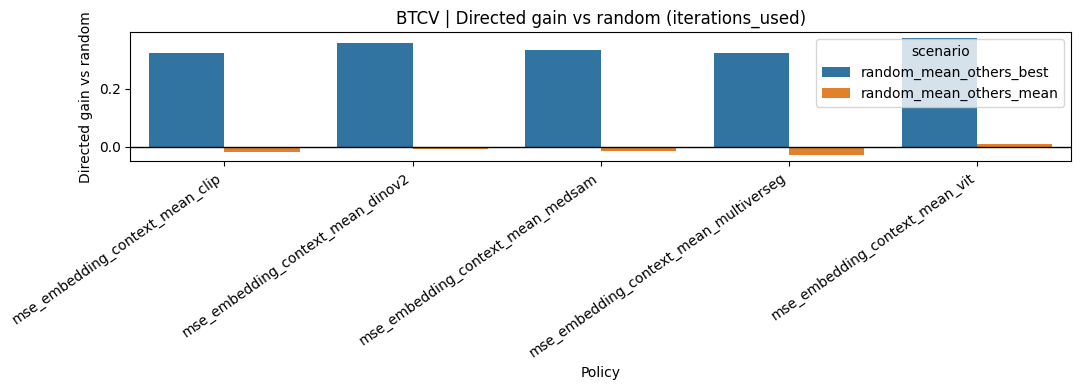

In [6]:
plot_rows = scenario_summary_with_delta[
    scenario_summary_with_delta['policy_name'] != BASELINE_POLICY
].copy()

for family_name, family_rows in plot_rows.groupby('family'):
    plt.figure(figsize=(11, 4))
    sns.barplot(
        data=family_rows,
        x='policy_name',
        y='directed_gain_vs_random',
        hue='scenario',
    )
    plt.axhline(0.0, color='black', linewidth=1)
    plt.title(f'{family_name} | Directed gain vs random ({METRIC})')
    plt.ylabel('Directed gain vs random')
    plt.xlabel('Policy')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

In [7]:
if SAVE_OUTPUTS:
    output_dir = REPO_ROOT / 'figures' / 'best_start_vs_mean_policy_analysis'
    output_dir.mkdir(parents=True, exist_ok=True)

    summary_path = output_dir / f'{PROCEDURE}_{ABLATION}_{(DATASET or "all").lower()}_{METRIC}_scenario_summary.csv'
    delta_path = output_dir / f'{PROCEDURE}_{ABLATION}_{(DATASET or "all").lower()}_{METRIC}_scenario_summary_with_delta.csv'

    scenario_summary.to_csv(summary_path, index=False)
    scenario_summary_with_delta.to_csv(delta_path, index=False)
    print(f'Wrote {summary_path}')
    print(f'Wrote {delta_path}')
else:
    print('SAVE_OUTPUTS=False (set to True to export CSVs).')

SAVE_OUTPUTS=False (set to True to export CSVs).
